In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

# Simple Usage

In [2]:
import sys
sys.path.append('../')
from CEmulator.Emulator import Xihm_CEmulator

emu = Xihm_CEmulator(verbose=True)

Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the ximm_cb emulator...
Using 129 training samples.
Loading the PkcbLin emulator...
Using 513 training samples.
Loading the PknnLin emulator...
Using 512 training samples [remove c0001 (no massive neutrino)].
The neutrino mass is treated as a single massive component.
Loading the Bk_lin emulator...
Using 129 training samples.
Loading the Bk_halofit emulator...
Using 129 training samples.
Loading the lgBk_lin2hmcode2020 emulator...
Using 513 training samples.
Loading the Bk_hmcode2020 emulator...
Using 129 training samples.
Loading the hmf_rockstar_M200m emulator...
Using 129 training samples.
Loading the hmf_fof_M200c emulator...
Using 129 training samples.
Loading the hmf_fof_M200m emulator...
Using 129 training samples.
Loading the hmf_rockstar_Mvir emulator...
U

In [3]:
%%time
Omegam = 0.3111
OmegaL = 0.6889
h      = 0.6766
sigma8 = 0.8102 
Omegab = 0.048975
ns     = 0.9665
mnu    = 0.06
Omegan = mnu/93.14/h/h
Omegac = Omegam - Omegab - Omegan
w0     = -1
wa     = 0
redshift = 0.50

# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)

rlist = np.logspace(-2, 2.5, 500)
zlist = np.array([redshift])
M_arr = np.array([1e13, 5e13, 1e14, 2e14])
xihmMassbin = emu.get_xihm_mass(z=zlist, r=rlist, M=M_arr)
print(xihmMassbin.shape)

The As is set to 2.106038e-09 (sigma8=0.810200) to match the input sigma8=0.810200.
(4, 1, 500)
CPU times: user 737 ms, sys: 9.4 ms, total: 746 ms
Wall time: 621 ms


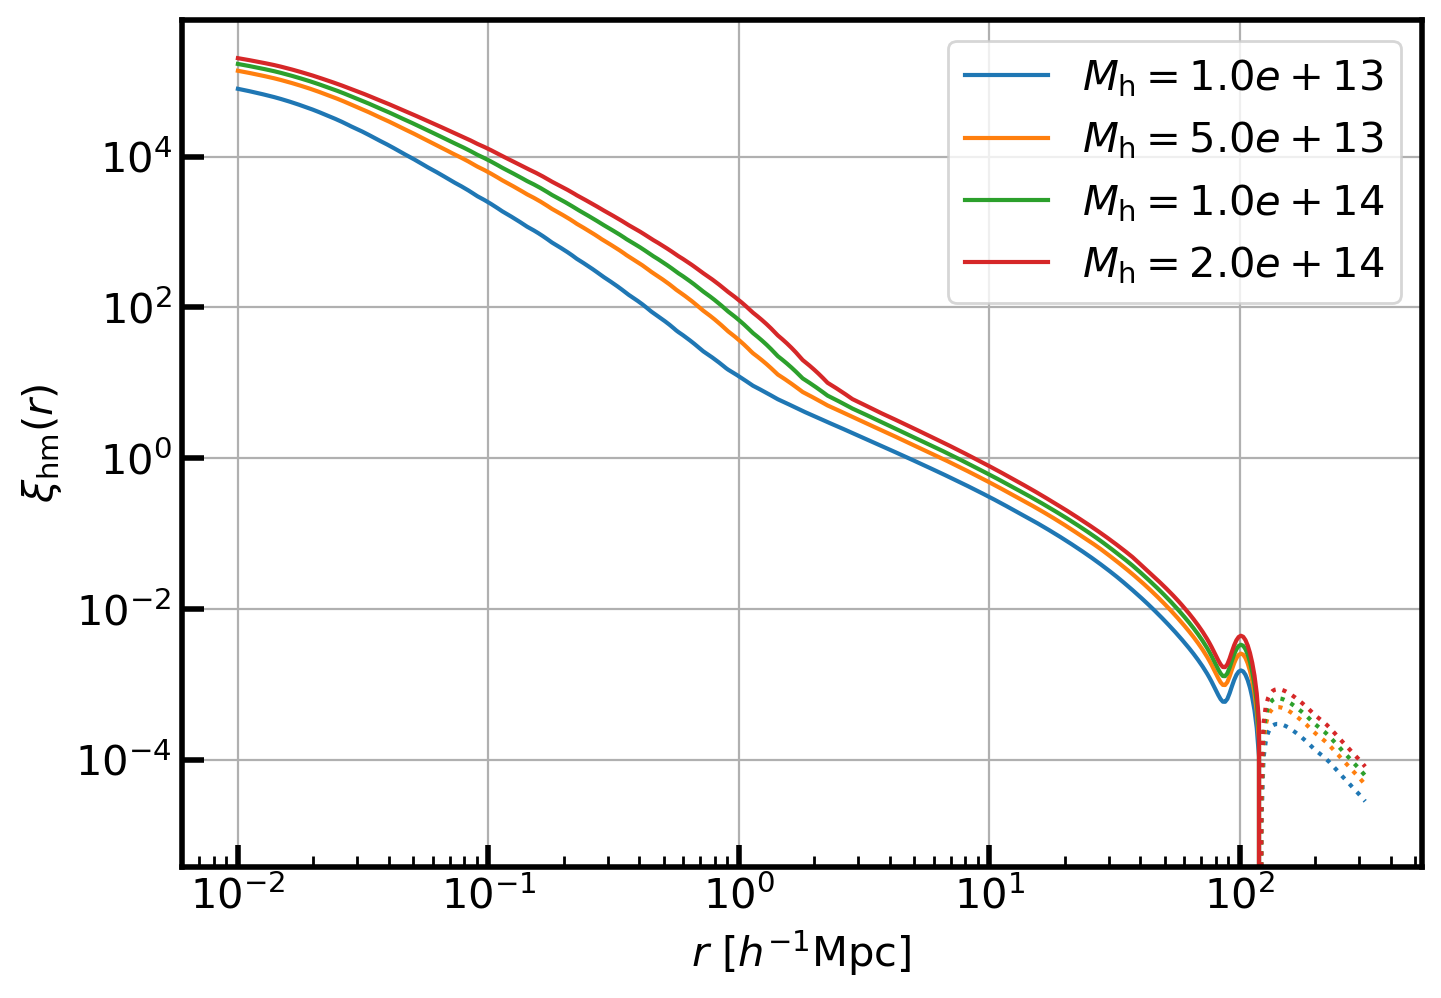

In [4]:
nmassbin  = len(M_arr)
with plt.style.context('article'):
    for im in range(nmassbin):
        l1, = plt.plot(rlist,  xihmMassbin[im, 0], label=r'$M_{\rm h} = %.1e$'%(M_arr[im]))
        l2, = plt.plot(rlist, -xihmMassbin[im, 0], ls=':', color=l1.get_color())
    plt.legend()
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(r'$\xi_{\rm hm}(r)$')
    plt.xlabel(r'$r\ [h^{-1}{\rm Mpc}]$')

In [5]:
rbins = np.concatenate([np.logspace(-2, 1, 30+1)[:-1],
                                np.arange(10, 50, 5)])
rmid  = (rbins[1:] + rbins[:-1]) / 2

xihm_sim = np.load("/Users/chenzhao/Desktop/mocktest/xihm_simu_n129_HybridNBin37_rockstar.npy")[0,8]
print(xihm_sim.shape, len(rmid))

lgdens = np.linspace(-5.0, -2.5, 6) 
xihm_emu = emu.get_xihm_lgnbar_threshold(r=rmid, z=redshift, lgden=lgdens)
print(xihm_emu.shape)
xihm_emu_tree = emu._get_xihm_lgnbar_threshold_tree(r=rmid, z=redshift, lgden=lgdens)
ximm_emu = emu.get_ximmlinear(r=rmid, z=redshift)[None, :,:]
xihm_emu_dire = emu.BrhmRockstarM200m.get_Brhm(r=rmid, z=redshift, lgden=lgdens) * ximm_emu

(13, 37) 37
(6, 1, 37)


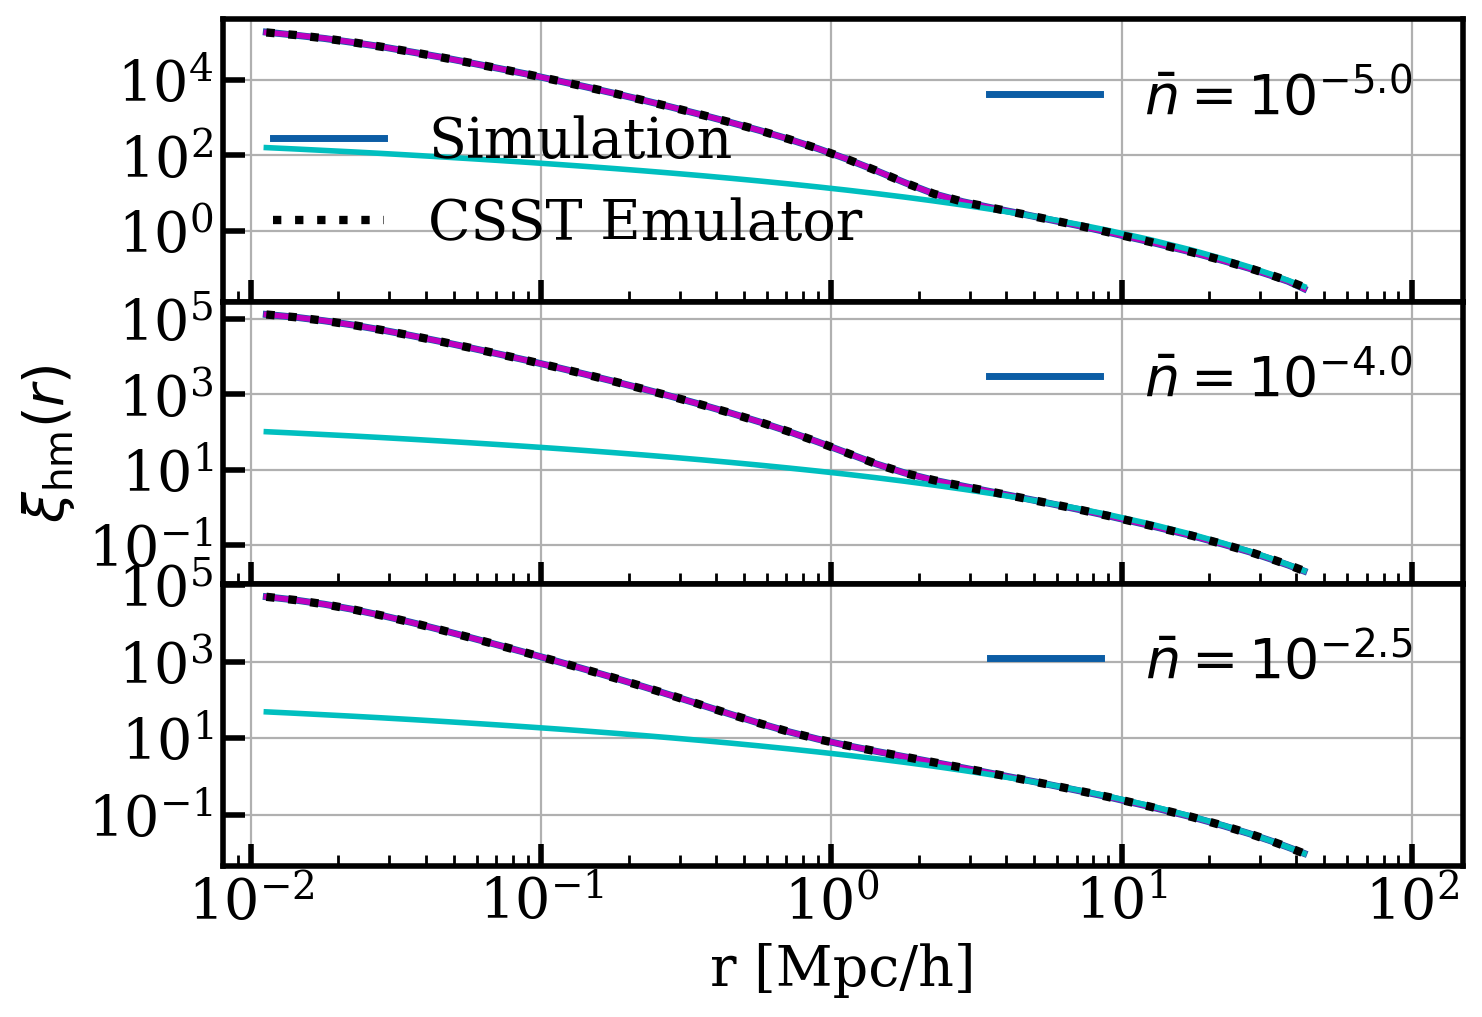

In [6]:
idensel = [0, 2, 5]
gridp   = plt.GridSpec(len(idensel), 1, wspace=0.0, hspace=0.0)
legstrs = [r"$\bar{n}=10^{%.1f}$"%(iden) for iden in lgdens]
with plt.style.context("mypresentation"):
    for pind, ii in enumerate(idensel):
        plt.subplot(gridp[pind])
        l1, = plt.loglog(rmid,  xihm_sim[7+ii], ls='-', label=legstrs[ii])
        l2, = plt.loglog(rmid,  xihm_emu[ii,0], color='k', ls=":", zorder=10, lw=3)
        plt.loglog(rmid,  xihm_emu_dire[ii,0], color='m', ls="-", lw=2.0)
        plt.loglog(rmid, xihm_emu_tree[ii,0], color='c', ls="-", lw=2.0)
        leg1 = plt.legend()
        if pind == 0:
            leg2 = plt.legend([l1,l2], ["Simulation", "CSST Emulator"], loc="lower left")
            plt.gca().add_artist(leg1)
        # plt.ylim([0.8, 1.2])
        plt.grid(True)
        plt.xlim([8e-3, 150])
        if pind == len(idensel)-1:
            plt.xlabel("r [Mpc/h]")
        else:
            plt.gca().set_xticklabels([])
        if pind == 1:
            plt.ylabel(r"$\xi_{\rm hm}(r)$")
        

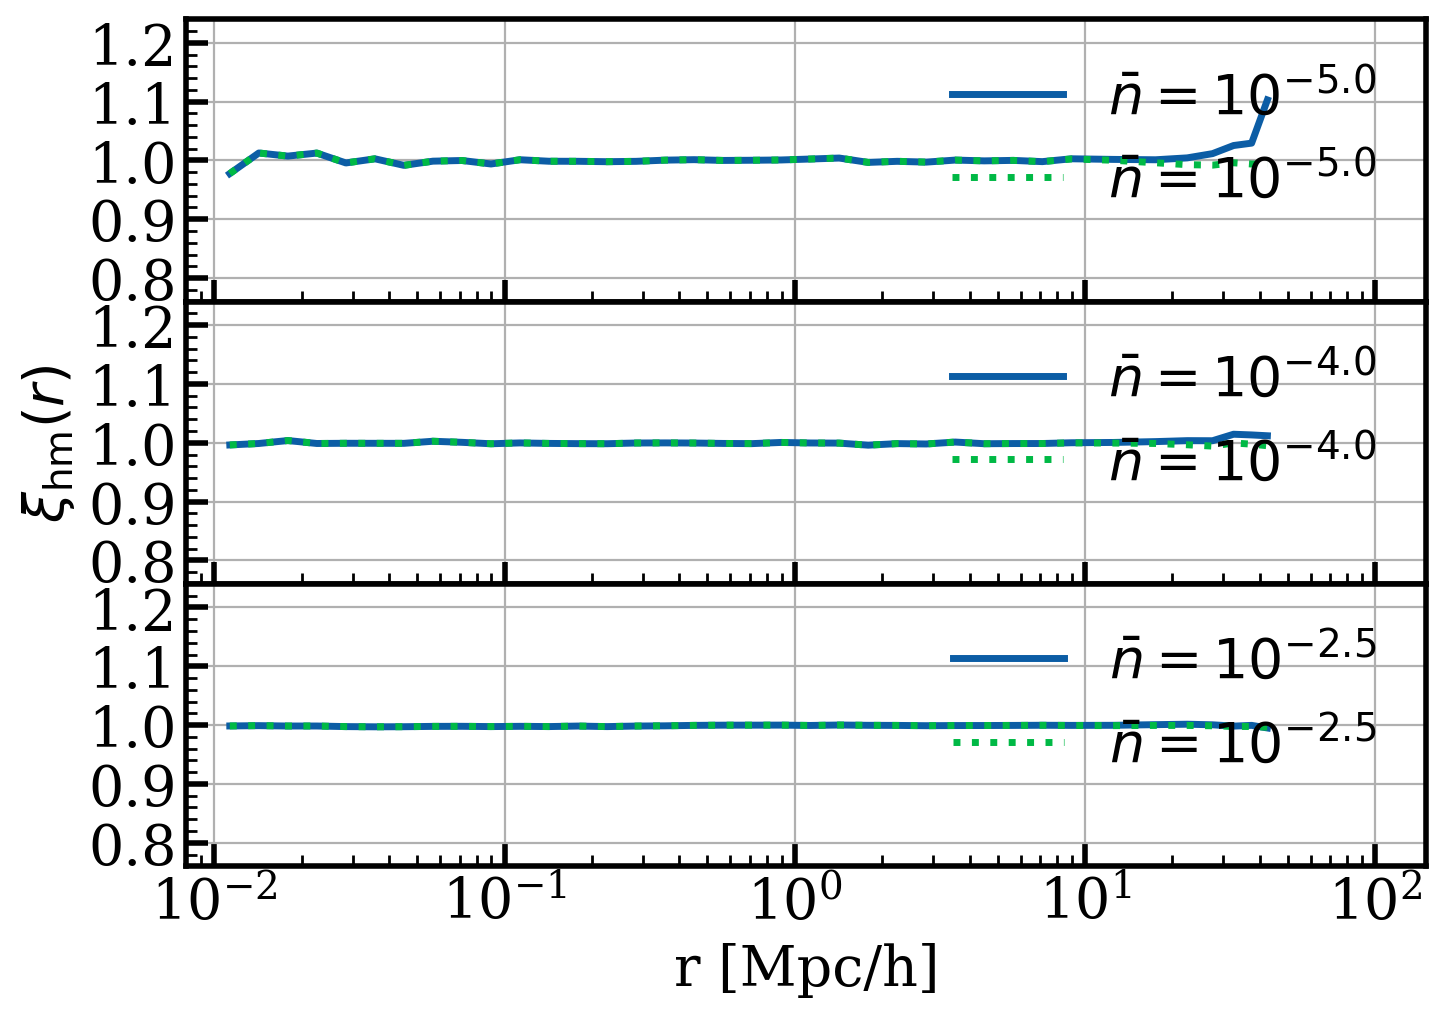

In [9]:
with plt.style.context("mypresentation"):
    for pind, ii in enumerate(idensel):
        plt.subplot(gridp[pind])
        l1, = plt.plot(rmid,  xihm_emu[ii,0]/xihm_sim[7+ii], ls='-', label=legstrs[ii])
        l1, = plt.plot(rmid,  xihm_emu_dire[ii,0]/xihm_sim[7+ii], ls=':', label=legstrs[ii])
         
        plt.xscale('log')
        leg1 = plt.legend()
        plt.ylim([0.76, 1.24])
        plt.grid(True)
        plt.xlim([8e-3, 150])
        if pind == len(idensel)-1:
            plt.xlabel("r [Mpc/h]")
        else:
            plt.gca().set_xticklabels([])
        if pind == 1:
            plt.ylabel(r"$\xi_{\rm hm}(r)$")